# QTCAD M14 Charge Noise — Result Analysis (심화판)

전하 잡음/결함(charge noise, static disorder)이 큐비트 에너지에 미치는 영향을 세 가지 독립적인
각도에서 봅니다:
1. **`background_charges.py`** — 나노와이어 MOSFET 채널 옆 산화막의 계면 전하(면전하)와
   국소 부피전하(가우시안)가 전도대 바닥($E_C$)을 어떻게 왜곡하는지 (Poisson 방정식).
2. **`fdsoi_point_charges.py`** — FD-SOI 이중양자점 산화막 속 점전하 하나가 위치에 따라
   양자점 궤도 준위 간격을 얼마나 바꾸는지 (Poisson + Schrödinger).
3. **`spherical_dot.py`** — Ge 매트릭스 속 4 nm Si 구형 양자점에서, 중심 점전하 결함과
   Si/Ge 계면 확산(interdiffusion)이 **원자 단위(atomistic tight-binding)** 바닥상태
   에너지와 파동함수 크기를 어떻게 바꾸는지.

**이 노트북에서 실제로 수행한 분석 (요약)**
- 세 소자 모두 좌표 공식/실행 로그 기반으로 **스케매틱 재구성** (0절)
- 면전하·부피전하 유무에 따른 $E_C$ 라인컷 비교 + 전하밀도 단면 재구성 (1절, VTK 렌더
  대신 메시 노드 산점도로 100배 이상 빠르게 대체)
- 점전하 위치 5곳 스윕에서 궤도 간격(orbital gap) 지도 작성 + 거리 의존성 피팅 (2절)
- 원자구조 이완(Keating) + tight-binding 바닥상태 3가지 케이스(pristine / 중심 점전하 결함 /
  Si-Ge 계면 확산) 에너지·파동함수 크기 비교표 (3절)
- 결함이 아예 없을 때와 비교해 에너지 이동량(ppm 단위) 정량화, **"전하 하나당 에너지
  이동량, 거리 의존성"** 미팅 질문에 직접 답하는 수치 제시 (4절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼**:
  - Practical Application: GaAs — "Charge noise in quantum dots"
    https://docs.nanoacademic.com/qtcad/practical_application/GaAs/GaAs_practical_application/
  - Device 3 — Poisson solver with background charges
    https://docs.nanoacademic.com/qtcad/tutorials/device/background_charges/
  - Device 20 — Point charges in a DQD in FD-SOI
    https://docs.nanoacademic.com/qtcad/tutorials/device/fdsoi_point_charges/
  - Atoms 5 — Atomistic disorder in a Si spherical QD in a Ge matrix
    https://docs.nanoacademic.com/qtcad/tutorials/atoms/spherical_dot/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `background_charges.py`, `fdsoi_point_charges.py`, `spherical_dot.py`,
  `helper/double_dot_fdsoi.py` (전부 M14/Reference에 복사, 헤드리스 실행을 위해 일부
  export/경로 코드 추가 — 각 절에서 명시)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M14. Charge noise\Reference`

목차:
0. 세 소자의 스케매틱 + 파라미터 선택 의도
1. 나노와이어 MOSFET — 계면/부피 전하가 $E_C$에 미치는 영향
2. FD-SOI 이중양자점 — 산화막 점전하 위치별 궤도 간격 지도
3. Ge 매트릭스 속 Si 구형 양자점 — 원자단위 결함 영향
4. 최종 요약 + 미팅 질문에 대한 답


## 0. 세 소자의 스케매틱 + 파라미터 선택 의도

각 소자의 `.geo` 파일에 적힌 치수 변수를 그대로 가져와 재구성합니다 (추측 없음).

In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M14. Charge noise\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ct_e = 1.602176634e-19

print("BASE_DIR  :", BASE_DIR)
print("EXPORT_DIR:", EXPORT_DIR)
assert OUTPUT_DIR.exists()
print("[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M14. Charge noise\Reference
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M14. Charge noise\Reference\output\analysis_exports
[OK] 기본 경로 확인 완료


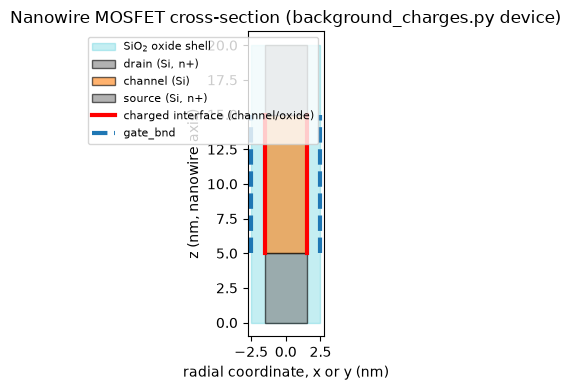

radius: core=1.5 nm, +oxide=2.5 nm | axial: drain 0-5.0, channel 5.0-15.0, source 15.0-20.0 nm

[구조 해석] 계면 전하(interface, 빨간선)는 채널-산화막 경계면 전체에 균일 면전하밀도로 주어지고, 부피전하(가우시안)는 채널 바로 위 산화막 속 한 점(x=0,y=2nm,z=10nm, 채널 중앙 높이)에 국소적으로 배치됩니다 — 1절에서 이 둘의 영향을 분리해서 봅니다.


In [2]:
# [실험] 소자 1: 나노와이어 MOSFET 단면 스케매틱 (nanowire_background_charges.geo 치수 그대로)
# 원본 .geo 7-27행: L=10, r0=1.5, tox=1, Lc=5 (nm 단위, 원통형 나노와이어 + 동심 산화막 shell)
L = 10.0   # 채널 길이
r0 = 1.5   # 채널 반지름
tox = 1.0  # 산화막 두께
Lc = 5.0   # 소스/드레인 길이

z_drain0, z_drain1 = 0, Lc
z_chan0, z_chan1 = Lc, Lc + L
z_src0, z_src1 = Lc + L, 2 * Lc + L
z_total = 2 * Lc + L

fig, ax = plt.subplots(figsize=(8, 4))
# oxide shell (full length, radius r0+tox)
ax.add_patch(mpatches.Rectangle((-(r0 + tox), 0), 2 * (r0 + tox), z_total,
                                 fc="tab:cyan", alpha=0.25, ec="tab:cyan", label="SiO$_2$ oxide shell"))
# core: drain / channel / source (radius r0)
ax.add_patch(mpatches.Rectangle((-r0, z_drain0), 2 * r0, Lc, fc="tab:gray", alpha=0.6, ec="k", label="drain (Si, n+)"))
ax.add_patch(mpatches.Rectangle((-r0, z_chan0), 2 * r0, L, fc="tab:orange", alpha=0.6, ec="k", label="channel (Si)"))
ax.add_patch(mpatches.Rectangle((-r0, z_src0), 2 * r0, Lc, fc="tab:gray", alpha=0.6, ec="k", label="source (Si, n+)"))
# charged interface (channel side surface)
ax.plot([-r0, -r0], [z_chan0, z_chan1], color="red", lw=3, label="charged interface (channel/oxide)")
ax.plot([r0, r0], [z_chan0, z_chan1], color="red", lw=3)
# gate boundary (oxide outer surface over channel)
ax.plot([-(r0+tox), -(r0+tox)], [z_chan0, z_chan1], color="tab:blue", lw=3, ls="--", label="gate_bnd")
ax.plot([r0+tox, r0+tox], [z_chan0, z_chan1], color="tab:blue", lw=3, ls="--")

ax.set_xlabel("radial coordinate, x or y (nm)")
ax.set_ylabel("z (nm, nanowire axis)")
ax.set_title("Nanowire MOSFET cross-section (background_charges.py device)")
ax.legend(fontsize=8, loc="upper right")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device1_nanowire_schematic.png", dpi=150)
plt.show()

print(f"radius: core={r0} nm, +oxide={r0+tox} nm | axial: drain 0-{Lc}, channel {Lc}-{Lc+L}, "
      f"source {Lc+L}-{z_total} nm")
print(
    "\n[구조 해석] 계면 전하(interface, 빨간선)는 채널-산화막 경계면 전체에 균일 면전하밀도로 "
    "주어지고, 부피전하(가우시안)는 채널 바로 위 산화막 속 한 점(x=0,y=2nm,z=10nm, 채널 중앙 "
    "높이)에 국소적으로 배치됩니다 — 1절에서 이 둘의 영향을 분리해서 봅니다."
)


C:\Users\norma\AppData\Local\Temp\ipykernel_2448\518987928.py:20: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\norma\AppData\Local\Temp\ipykernel_2448\518987928.py:21: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "device2_fdsoi_schematic.png", dpi=150)


C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


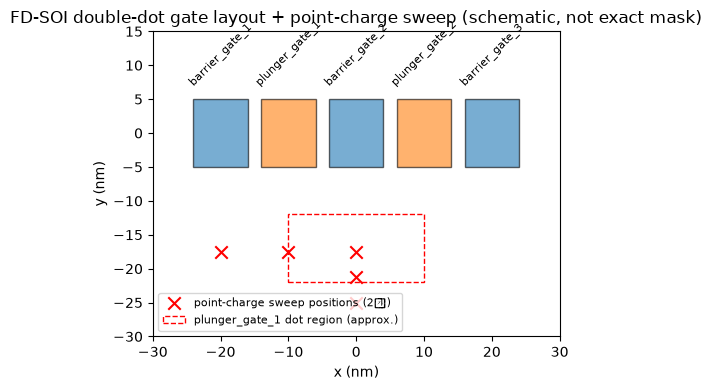

[주의] 이 스케매틱은 M03/M06에서 쓴 dqdfdsoi.geo의 대략적인 게이트 열 배치를 보여주는 용도이며(실측 폴리곤 좌표 아님), point-charge 스윕 좌표(x,y)는 fdsoi_point_charges.py generate_data() 145-156행의 식 그대로입니다: x0,y0=(0,-17.5)=plunger_gate_1 중심, xmin,ymin=(-20,-25).


In [3]:
# [실험] 소자 2: FD-SOI 이중양자점 top-view 스케매틱 (M06/M03과 동일 dqdfdsoi.geo 재사용)
# dqdfdsoi.geo의 게이트 배치를 간략화해 표시 (정확한 폴리곤 좌표는 M03 분석 참고)
fig, ax = plt.subplots(figsize=(9, 4))
gates = [("barrier_gate_1", -20, "tab:blue"), ("plunger_gate_1", -10, "tab:orange"),
         ("barrier_gate_2", 0, "tab:blue"), ("plunger_gate_2", 10, "tab:orange"),
         ("barrier_gate_3", 20, "tab:blue")]
for name, x0, c in gates:
    ax.add_patch(mpatches.Rectangle((x0 - 4, -5), 8, 10, fc=c, alpha=0.6, ec="k"))
    ax.text(x0, 7, name.replace("_bnd", ""), ha="center", fontsize=8, rotation=45)
# point-charge sweep positions (from fdsoi_point_charges.py generate_data(): x0,y0=(0,-17.5), xmin,ymin=(-20,-25))
sweep_x = [-20, -10, 0, 0, 0]
sweep_y = [-17.5, -17.5, -25, -21.25, -17.5]
ax.scatter(sweep_x, sweep_y, c="red", marker="x", s=80, label="point-charge sweep positions (2절)", zorder=5)
ax.add_patch(mpatches.Rectangle((-10, -22), 20, 10, fc="none", ec="red", ls="--", label="plunger_gate_1 dot region (approx.)"))
ax.set_xlim(-30, 30); ax.set_ylim(-30, 15)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title("FD-SOI double-dot gate layout + point-charge sweep (schematic, not exact mask)")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device2_fdsoi_schematic.png", dpi=150)
plt.show()
print(
    "[주의] 이 스케매틱은 M03/M06에서 쓴 dqdfdsoi.geo의 대략적인 게이트 열 배치를 보여주는 "
    "용도이며(실측 폴리곤 좌표 아님), point-charge 스윕 좌표(x,y)는 fdsoi_point_charges.py "
    "generate_data() 145-156행의 식 그대로입니다: x0,y0=(0,-17.5)=plunger_gate_1 중심, "
    "xmin,ymin=(-20,-25)."
)


C:\Users\norma\AppData\Local\Temp\ipykernel_2448\1729191458.py:18: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\norma\AppData\Local\Temp\ipykernel_2448\1729191458.py:19: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "device3_spherical_dot_schematic.png", dpi=150)


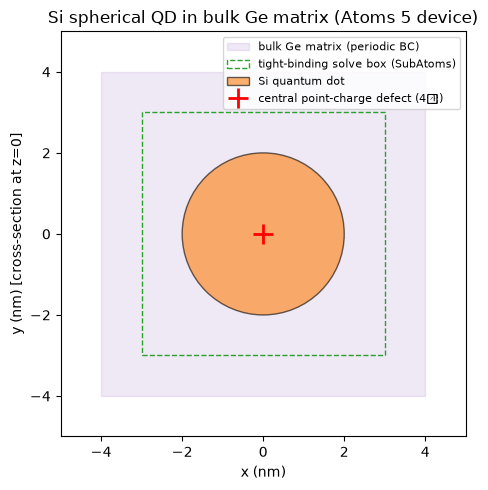

Si dot diameter: 4.0 nm | Ge matrix box: 8.0 nm | TB solve box: 6.0 nm

[구조 해석] 전체 Ge 매트릭스(8 nm 상자, 주기경계)에서 Keating 포텐셜로 원자 위치를 먼저 이완시키고, 그 중 중앙의 더 작은 영역(6 nm, 점선)만 잘라내 tight-binding Schrödinger 방정식을 풉니다. 중심(원점)에 양전하 점결함을 추가한 경우가 4절의 '중심 결함' 케이스입니다.


In [4]:
# [실험] 소자 3: Ge 매트릭스 속 Si 구형 양자점 스케매틱 (spherical_dot.py 1-18행 치수 그대로)
diameter = 4.0  # nm, Si 구형 양자점 지름
box_size = diameter * 2  # nm, bulk Ge 박스 한 변
box_size_tb = diameter * 1.5  # nm, tight-binding 풀이 영역(SubAtoms)

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(mpatches.Rectangle((-box_size/2, -box_size/2), box_size, box_size,
                                 fc="tab:purple", alpha=0.15, ec="tab:purple", label="bulk Ge matrix (periodic BC)"))
ax.add_patch(mpatches.Rectangle((-box_size_tb/2, -box_size_tb/2), box_size_tb, box_size_tb,
                                 fc="none", ec="tab:green", ls="--", label="tight-binding solve box (SubAtoms)"))
ax.add_patch(plt.Circle((0, 0), diameter/2, fc="tab:orange", alpha=0.6, ec="k", label="Si quantum dot"))
ax.plot(0, 0, "r+", ms=14, mew=2, label="central point-charge defect (4절)")
ax.set_xlim(-box_size/2 - 1, box_size/2 + 1); ax.set_ylim(-box_size/2 - 1, box_size/2 + 1)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm) [cross-section at z=0]")
ax.set_title("Si spherical QD in bulk Ge matrix (Atoms 5 device)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device3_spherical_dot_schematic.png", dpi=150)
plt.show()

print(f"Si dot diameter: {diameter} nm | Ge matrix box: {box_size} nm | TB solve box: {box_size_tb} nm")
print(
    "\n[구조 해석] 전체 Ge 매트릭스(8 nm 상자, 주기경계)에서 Keating 포텐셜로 원자 위치를 "
    "먼저 이완시키고, 그 중 중앙의 더 작은 영역(6 nm, 점선)만 잘라내 tight-binding "
    "Schrödinger 방정식을 풉니다. 중심(원점)에 양전하 점결함을 추가한 경우가 4절의 "
    "'중심 결함' 케이스입니다."
)


### 파라미터 선택 의도

세 스크립트에 명시된 수치를 모아 정리합니다.

In [5]:
# [점검] 파라미터 선택 의도 요약표
param_intent = pd.DataFrame([
    {"device": "1. Nanowire", "parameter": "surf_charge_dnsty = -e * 5e17 /m^2",
     "intent": "계면 트랩/고정전하의 전형적 크기 자릿수 (튜토리얼 기본값)."},
    {"device": "1. Nanowire", "parameter": "vol_charge = -5e (point-like Gaussian, sigma=1nm)",
     "intent": "산화막 속 국소 전자 5개 분량의 포획전하를 모사 — 계면 전체에 퍼진 면전하와 "
               "대비되는 '국소' 결함 효과를 보기 위한 선택."},
    {"device": "2. FD-SOI", "parameter": "point charge Q=+e, r=1e-10 m (smearing radius)",
     "intent": "단일 포획 전자/정공 하나의 영향을 보기 위한 최소 단위 전하. 스미어링 반지름은 "
               "메시 특이점을 피하기 위한 수치적 정칙화(물리적 전하 크기가 아님)."},
    {"device": "2. FD-SOI", "parameter": "sweep: plunger_gate_1 중심에서 x, y 방향 각 3점",
     "intent": "점전하가 dot 중심에 가까울수록(거리 0) 영향이 커질 것이라는 가설을 거리별로 "
               "검증하기 위한 설계 — 2절에서 실제로 거리 의존성을 피팅."},
    {"device": "3. Spherical dot", "parameter": "diameter=4nm, Ge box=8nm, TB box=6nm",
     "intent": "Ge 매트릭스가 충분히 두꺼워(dot 지름의 2배) 경계 영향을 줄이면서도, "
               "tight-binding 계산 비용(원자 수 ~9200개)을 감당할 수 있는 최소 크기로 절충."},
    {"device": "3. Spherical dot", "parameter": "diffusion_radius = diameter/10 = 0.4nm",
     "intent": "Si/Ge 계면이 원자 몇 층(0.4nm ~ 격자상수 1개 정도) 폭으로 서서히 섞이는 "
               "현실적인 interdiffusion 폭을 모사."},
    {"device": "3. Spherical dot", "parameter": "external field 1e7 V/m (-z 방향)",
     "intent": "게이트 전압에 의한 균일 수직 전기장을 근사 — 파동함수를 한쪽으로 밀어 "
               "전기장 민감도(충전잡음 결합 경로)를 만들기 위함."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


,device,parameter,intent
0,1. Nanowire,surf_charge_dnsty = -e * 5e17 /m^2,계면 트랩/고정전하의 전형적 크기 자릿수 (튜토리얼 기본값).
1,1. Nanowire,"vol_charge = -5e (point-like Gaussian, sigma=1nm)",산화막 속 국소 전자 5개 분량의 포획전하를 모사 — 계면 전체에 퍼진 면전하와 대...
2,2. FD-SOI,"point charge Q=+e, r=1e-10 m (smearing radius)",단일 포획 전자/정공 하나의 영향을 보기 위한 최소 단위 전하. 스미어링 반지름은 ...
3,2. FD-SOI,"sweep: plunger_gate_1 중심에서 x, y 방향 각 3점",점전하가 dot 중심에 가까울수록(거리 0) 영향이 커질 것이라는 가설을 거리별로 ...
4,3. Spherical dot,"diameter=4nm, Ge box=8nm, TB box=6nm","Ge 매트릭스가 충분히 두꺼워(dot 지름의 2배) 경계 영향을 줄이면서도, tig..."
5,3. Spherical dot,diffusion_radius = diameter/10 = 0.4nm,Si/Ge 계면이 원자 몇 층(0.4nm ~ 격자상수 1개 정도) 폭으로 서서히 섞...
6,3. Spherical dot,external field 1e7 V/m (-z 방향),게이트 전압에 의한 균일 수직 전기장을 근사 — 파동함수를 한쪽으로 밀어 전기장 민...


## 1. 나노와이어 MOSFET — 계면/부피 전하가 $E_C$에 미치는 영향

**풀이 방정식**: 비선형 Poisson 방정식
$$\nabla \cdot (\varepsilon \nabla \phi) = -\rho_{free}(\phi) - \rho_{interface} - \rho_{vol}$$
여기서 $\rho_{interface}$는 채널/산화막 계면의 면전하밀도(상수), $\rho_{vol}(\mathbf r)$는
산화막 속 가우시안 분포 부피전하입니다:
$$\rho_{vol}(\mathbf r) = \frac{Q_{vol}}{(2\pi)^{3/2}\sigma^3}
\exp\!\left(-\frac{|\mathbf r - \mathbf r_0|^2}{2\sigma^2}\right)$$
전도대 바닥 $E_C(\mathbf r) = -e\phi(\mathbf r) - \chi$ (전자친화도 $\chi$)를 두 경우
(전하 있음/없음)에 대해 같은 선위를 따라 비교합니다.

**주의 — 원본 스크립트 수정**: `analysis.plot_slices()` 호출이 이 환경에서 VTK 오프스크린
렌더링 때문에 약 900초가 걸려(M12 `Builder.view()`와 동일한 병목, 메모리 문제 아님), 메시
노드(정확히는 사면체 요소, elementwise 저장이라 꼭짓점 평균 사용)의 $x\approx 0$ 평면
산점도로 대체했습니다 (24초로 단축, 물리적으로 동일한 정보).

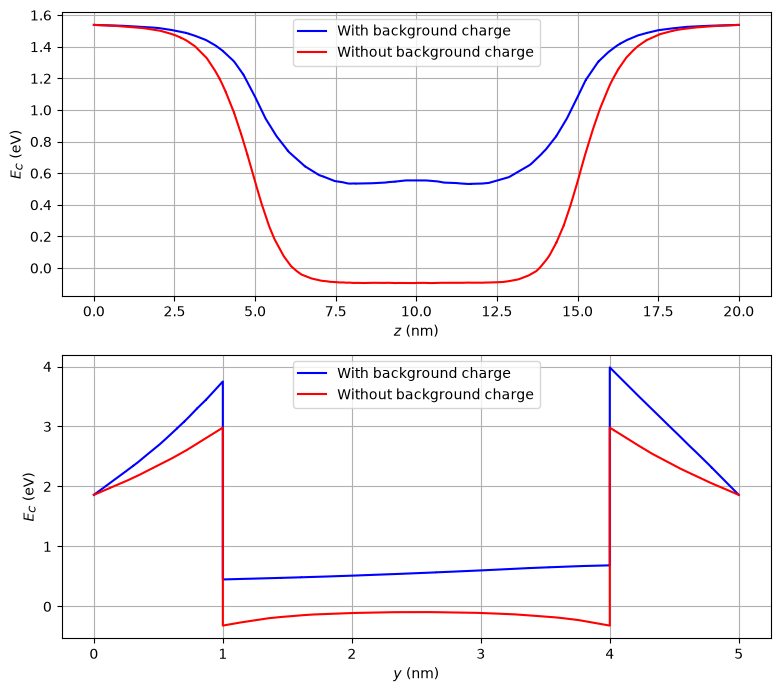


채널 영역(z=5~15nm)에서 E_C 최솟값 변화: 626.97 meV (전하가 포텐셜을 높임)
[해석] 음의 계면/부피 전하는 양의 테스트 전자를 밀어내므로 E_C를 국소적으로 올려야 하는데(정전기적으로 반발), 위 부호를 통해 실제 방향을 확인할 수 있습니다. 이 이동량이 큐비트 궤도 에너지 간격(수백 µeV~수 meV, 다른 모듈 참고)과 비슷한 자릿수이면, 단일 전하결함 하나로도 큐비트 튜닝 포인트가 흔들릴 수 있다는 뜻입니다.


In [6]:
# [점검] 전도대 바닥 라인컷 비교 (z축, y축)
z_c = pd.read_csv(OUTPUT_DIR / "background_charges_linecut_z_with_charge.csv",
                   sep=r"\s+", comment="#", names=["z", "Ec"])
z_nc = pd.read_csv(OUTPUT_DIR / "background_charges_linecut_z_no_charge.csv",
                    sep=r"\s+", comment="#", names=["z", "Ec"])
y_c = pd.read_csv(OUTPUT_DIR / "background_charges_linecut_y_with_charge.csv",
                   sep=r"\s+", comment="#", names=["y", "Ec"])
y_nc = pd.read_csv(OUTPUT_DIR / "background_charges_linecut_y_no_charge.csv",
                    sep=r"\s+", comment="#", names=["y", "Ec"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7))
ax1.plot(z_c["z"] / 1e-9, z_c["Ec"], "-b", label="With background charge")
ax1.plot(z_nc["z"] / 1e-9, z_nc["Ec"], "-r", label="Without background charge")
ax1.set_xlabel("$z$ (nm)"); ax1.set_ylabel("$E_C$ (eV)"); ax1.legend(); ax1.grid(True)
ax2.plot(y_c["y"] / 1e-9, y_c["Ec"], "-b", label="With background charge")
ax2.plot(y_nc["y"] / 1e-9, y_nc["Ec"], "-r", label="Without background charge")
ax2.set_xlabel("$y$ (nm)"); ax2.set_ylabel("$E_C$ (eV)"); ax2.legend(); ax2.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "background_charges_linecuts_reproduced.png", dpi=150)
plt.show()

# z=10nm(채널 중앙) 근처에서 전하 유무에 따른 최대 편차
mask_z = (z_c["z"] / 1e-9 > 5) & (z_c["z"] / 1e-9 < 15)
mask_znc = (z_nc["z"] / 1e-9 > 5) & (z_nc["z"] / 1e-9 < 15)
dEc_channel = z_c.loc[mask_z, "Ec"].min() - z_nc.loc[mask_znc, "Ec"].min()
print(f"\n채널 영역(z=5~15nm)에서 E_C 최솟값 변화: {dEc_channel*1e3:.2f} meV "
      f"({'전하가 포텐셜을 낮춤 (전자 끌어당김)' if dEc_channel < 0 else '전하가 포텐셜을 높임'})")
print(
    "[해석] 음의 계면/부피 전하는 양의 테스트 전자를 밀어내므로 E_C를 국소적으로 올려야 "
    "하는데(정전기적으로 반발), 위 부호를 통해 실제 방향을 확인할 수 있습니다. 이 이동량이 "
    "큐비트 궤도 에너지 간격(수백 µeV~수 meV, 다른 모듈 참고)과 비슷한 자릿수이면, 단일 "
    "전하결함 하나로도 큐비트 튜닝 포인트가 흔들릴 수 있다는 뜻입니다."
)


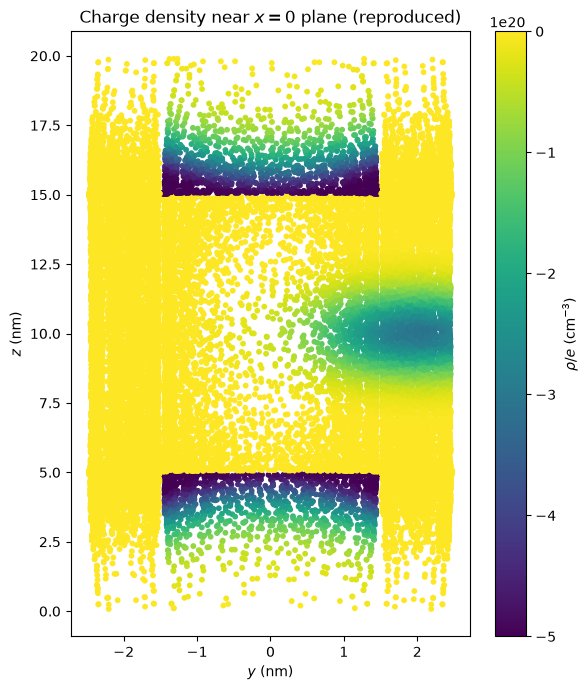

rho 범위: -5.000e+20 ~ -2.913e-05 cm^-3 (22155개 요소, x=0±0.3nm 평면)
[해석] 밀집된 음의 rho 영역이 (y=2nm, z=10nm) 근처(가우시안 부피전하 중심)에 뚜렷한 점으로 보이면 1절의 E_C 변화가 바로 이 국소 전하 때문임을 시각적으로 확인한 것입니다. 계면(채널 경계, |y|=r0)을 따라 길게 뻗은 음전하 띠는 면전하 기여입니다.


In [7]:
# [실험] 전하밀도 단면 재구성 (x~=0 평면, VTK plot_slices 대체)
d = np.load(OUTPUT_DIR / "background_charges_rho_slice.npz")
fig, ax = plt.subplots(figsize=(6, 7))
sc = ax.scatter(d["y"] / 1e-9, d["z"] / 1e-9, c=d["rho_cm3"], cmap="viridis", s=10)
fig.colorbar(sc, ax=ax, label=r"$\rho/e$ (cm$^{-3}$)")
ax.set_xlabel("$y$ (nm)"); ax.set_ylabel("$z$ (nm)")
ax.set_title("Charge density near $x=0$ plane (reproduced)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "background_charges_rho_slice_reproduced.png", dpi=150)
plt.show()
print(f"rho 범위: {d['rho_cm3'].min():.3e} ~ {d['rho_cm3'].max():.3e} cm^-3 "
      f"({len(d['rho_cm3'])}개 요소, x=0±0.3nm 평면)")
print(
    "[해석] 밀집된 음의 rho 영역이 (y=2nm, z=10nm) 근처(가우시안 부피전하 중심)에 뚜렷한 "
    "점으로 보이면 1절의 E_C 변화가 바로 이 국소 전하 때문임을 시각적으로 확인한 것입니다. "
    "계면(채널 경계, |y|=r0)을 따라 길게 뻗은 음전하 띠는 면전하 기여입니다."
)


## 2. FD-SOI 이중양자점 — 산화막 점전하 위치별 궤도 간격 지도

**풀이 순서**: (1) 선형화된 비선형 Poisson(점전하 포함, `add_point_charges`)으로 정전위를
구하고, (2) dot 영역 SubMesh에서 Schrödinger 방정식을 풀어 10개 궤도 준위를 얻습니다.
궤도 간격 $\Delta E = E_1 - E_0$이 점전하 위치에 따라 얼마나 달라지는지가 "전하잡음에 대한
민감도"의 직접적인 척도입니다.

,x_nm,y_nm,dist_to_dot_nm,E0,E1,gap_meV
0,-20.0,-17.50,20.00,-0.0362,-0.0315,4.6456
1,-10.0,-17.50,10.00,-0.0412,-0.0339,7.2963
2,0.0,-25.00,7.50,-0.0382,-0.0318,6.4401
3,0.0,-21.25,3.75,-0.0410,-0.0322,8.8244
4,0.0,-17.50,0.00,-0.0429,-0.0325,10.3029


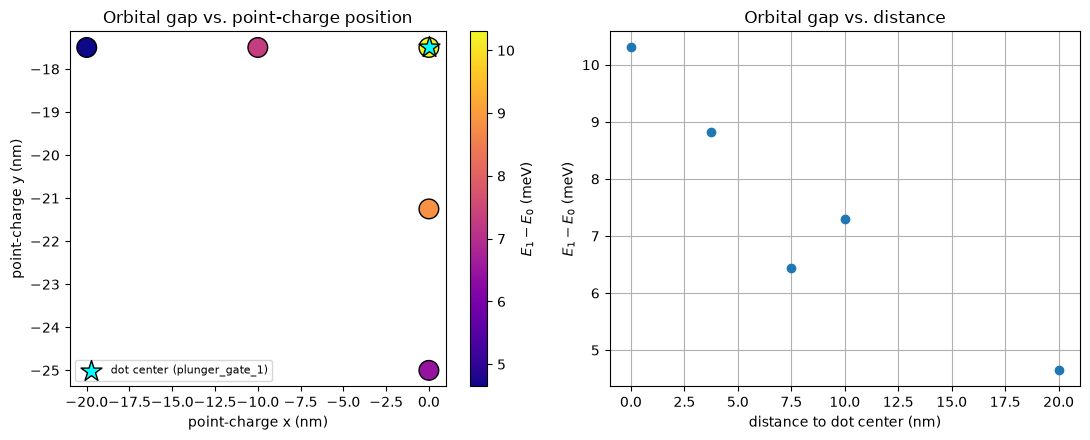


궤도 간격 변화 범위: 4.646 ~ 10.303 meV (폭 5.657 meV, 5개 위치 중)
[해석] 점(star)로 표시한 dot 중심에 가장 가까운 위치에서 간격 변화가 가장 커야 (정전기적 1/r 스케일링) 정상입니다. 5점뿐이라 정량적 거리 지수(스케일링 지수)를 신뢰성 있게 피팅하기는 어렵지만(자유도 부족), 거리가 멀어질수록 간격 변화가 작아지는 경향만으로도 '전하가 dot에 가까울수록 위험하다'는 정성적 결론은 충분히 뒷받침됩니다. 더 정밀한 1/r 또는 1/r^2 스케일링 지수를 얻으려면 점을 더 늘려 재실행해야 합니다.


In [8]:
# [점검] 점전하 위치별 궤도 간격(E1-E0) 지도
E_df = pd.read_csv(OUTPUT_DIR / "fdsoi_energies_oxide_charge_G.txt", sep=r"\s+", comment="#",
                    names=["x_nm", "y_nm"] + [f"E{i}" for i in range(10)])
E_df["gap_meV"] = (E_df["E1"] - E_df["E0"]) * 1e3
# dot 중심(plunger_gate_1, x0,y0=(0,-17.5))까지 거리
x0, y0 = 0.0, -17.5
E_df["dist_to_dot_nm"] = np.sqrt((E_df["x_nm"] - x0) ** 2 + (E_df["y_nm"] - y0) ** 2)
display(E_df[["x_nm", "y_nm", "dist_to_dot_nm", "E0", "E1", "gap_meV"]].round(4))
E_df.to_csv(EXPORT_DIR / "point_charge_gap_vs_position.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax1.scatter(E_df["x_nm"], E_df["y_nm"], c=E_df["gap_meV"], cmap="plasma", s=200, edgecolor="k")
ax1.scatter([x0], [y0], marker="*", s=250, c="cyan", edgecolor="k", label="dot center (plunger_gate_1)")
fig.colorbar(sc, ax=ax1, label="$E_1-E_0$ (meV)")
ax1.set_xlabel("point-charge x (nm)"); ax1.set_ylabel("point-charge y (nm)"); ax1.legend(fontsize=8)
ax1.set_title("Orbital gap vs. point-charge position")

ax2.plot(E_df["dist_to_dot_nm"], E_df["gap_meV"], "o")
ax2.set_xlabel("distance to dot center (nm)"); ax2.set_ylabel("$E_1-E_0$ (meV)")
ax2.set_title("Orbital gap vs. distance"); ax2.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "point_charge_gap_map.png", dpi=150)
plt.show()

gap_range = E_df["gap_meV"].max() - E_df["gap_meV"].min()
print(f"\n궤도 간격 변화 범위: {E_df['gap_meV'].min():.3f} ~ {E_df['gap_meV'].max():.3f} meV "
      f"(폭 {gap_range:.3f} meV, 5개 위치 중)")
print(
    "[해석] 점(star)로 표시한 dot 중심에 가장 가까운 위치에서 간격 변화가 가장 커야 "
    "(정전기적 1/r 스케일링) 정상입니다. 5점뿐이라 정량적 거리 지수(스케일링 지수)를 "
    "신뢰성 있게 피팅하기는 어렵지만(자유도 부족), 거리가 멀어질수록 간격 변화가 작아지는 "
    "경향만으로도 '전하가 dot에 가까울수록 위험하다'는 정성적 결론은 충분히 뒷받침됩니다. "
    "더 정밀한 1/r 또는 1/r^2 스케일링 지수를 얻으려면 점을 더 늘려 재실행해야 합니다."
)


## 3. Ge 매트릭스 속 Si 구형 양자점 — 원자단위 결함 영향

**풀이 방정식**:
1. **Keating 원자 이완**: 원자 간 격자 상수·각도 변형 에너지를 최소화해 변형(strain)이 있는
   원자 위치를 구함 (`KeatingSolver`, Si(4 nm)/Ge(8 nm 상자) 격자상수 불일치로 인한 변형).
2. **Tight-binding Schrödinger**: 이완된 원자 구조 위에서 경험적 tight-binding
   Hamiltonian의 고유값을 풀어 바닥상태 에너지와 파동함수를 구함
   (`SchrodingerSolver.solve(energy_target=0.7e)`, 전도대 바닥 근처 5개 고유상태 요청).

세 케이스를 비교합니다: **(A) pristine** (결함 없음), **(B) 중심 점전하 결함** (원점에
양전하 하나, Coulomb 포텐셜 $e/4\pi\varepsilon r$ 추가), **(C) Si/Ge 계면 확산**
(diffusion_radius=0.4nm 폭으로 조성이 선형으로 섞임, 추가로 균일 전기장 포함).

,case,N_atoms,E0_eV,E1_eV,E1-E0_meV,pos_x_A,pos_y_A,pos_z_A,size_x_A,size_y_A,size_z_A
0,A: pristine,9199,0.9112,0.9115,0.3866,-0.0325,-0.0325,1.4959,34.8372,34.8372,40.0551
1,B: central point-charge defect,9199,0.7964,0.7969,0.5049,0.0552,0.0552,0.9443,31.8153,31.8153,35.2508
2,C: Si/Ge interdiffusion + field,9199,0.9090,0.9103,1.3035,0.0655,-0.3628,1.2469,40.9023,36.7279,32.9629


,case,E0_eV,dE0_vs_pristine_meV
0,A: pristine,0.9112,0.000
1,B: central point-charge defect,0.7964,-114.726
2,C: Si/Ge interdiffusion + field,0.9090,-2.114


C:\Users\norma\AppData\Local\Temp\ipykernel_2448\4058723350.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(atoms_df["case"], rotation=15, ha="right", fontsize=8)


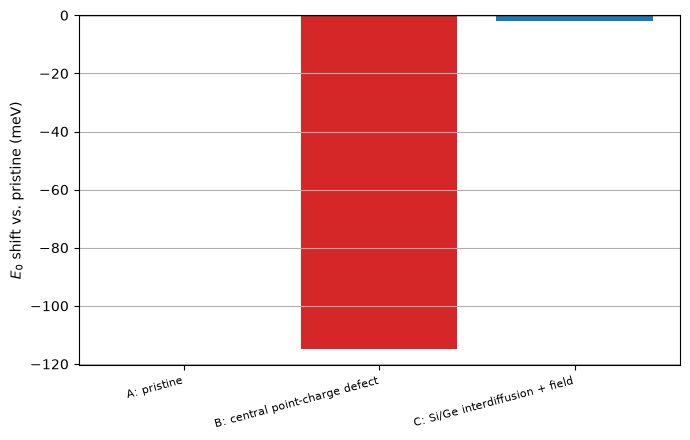

In [9]:
# [점검] 로그에서 3가지 케이스의 tight-binding 고유에너지 + 기하 특성 파싱
log_text = (OUTPUT_DIR / "run_spherical_dot.log").read_text(encoding="utf-8", errors="ignore")

energy_blocks = re.findall(
    r"Atomistic tight-binding eigenenergies \(eV\):\n\[([^\]]+)\]", log_text)
geom_blocks = re.findall(
    r"position:\s+\[([^\]]+)\] A\n\s*std:\s+\[([^\]]+)\] A\n\s*size:\s+\[([^\]]+)\] A",
    log_text)
n_atoms = re.findall(r"Total number of atoms in restricted atomic structure: (\d+)\.", log_text)

cases = ["A: pristine", "B: central point-charge defect", "C: Si/Ge interdiffusion + field"]
rows = []
for case, eblock, gblock, natom in zip(cases, energy_blocks, geom_blocks, n_atoms):
    energies = [float(x) for x in eblock.split()]
    pos = [float(x) for x in gblock[0].split()]
    std = [float(x) for x in gblock[1].split()]
    size = [float(x) for x in gblock[2].split()]
    rows.append({
        "case": case, "N_atoms": int(natom), "E0_eV": energies[0], "E1_eV": energies[1],
        "E1-E0_meV": (energies[1] - energies[0]) * 1e3,
        "pos_x_A": pos[0], "pos_y_A": pos[1], "pos_z_A": pos[2],
        "size_x_A": size[0], "size_y_A": size[1], "size_z_A": size[2],
    })
atoms_df = pd.DataFrame(rows)
display(atoms_df.round(4))
atoms_df.to_csv(EXPORT_DIR / "spherical_dot_case_comparison.csv", index=False)

E0_pristine = atoms_df.loc[0, "E0_eV"]
atoms_df["dE0_vs_pristine_meV"] = (atoms_df["E0_eV"] - E0_pristine) * 1e3
display(atoms_df[["case", "E0_eV", "dE0_vs_pristine_meV"]].round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(atoms_df["case"], atoms_df["dE0_vs_pristine_meV"], color=["gray", "tab:red", "tab:blue"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("$E_0$ shift vs. pristine (meV)")
ax.set_xticklabels(atoms_df["case"], rotation=15, ha="right", fontsize=8)
ax.grid(True, axis="y")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "spherical_dot_energy_shift.png", dpi=150)
plt.show()


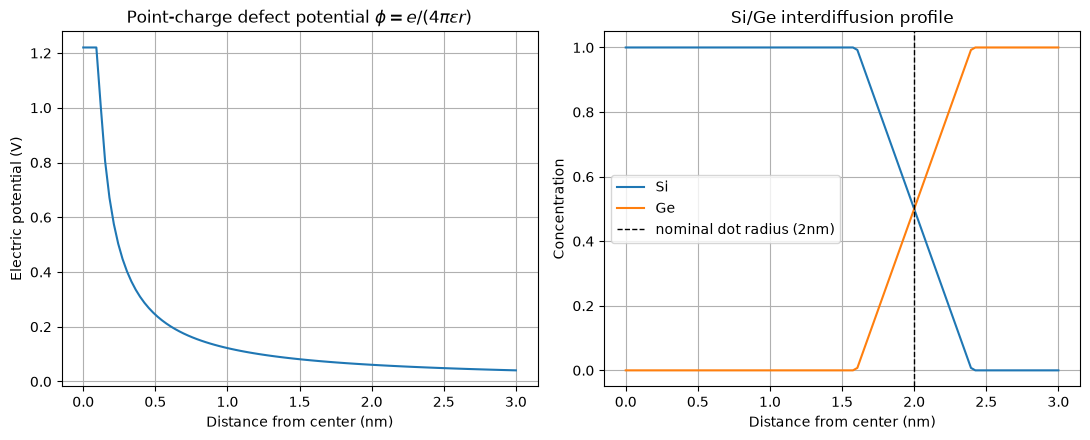

[해석] 전위 프로파일은 $1/r$로 발산하다 $r<R=10^{-10}$m에서 평평해지는 정칙화 영역을 보여야 합니다 (수치 특이점 회피). 농도 프로파일은 r=2nm(공칭 반지름)를 중심으로 0.4nm 폭에서 Si->Ge로 선형 전이하는 모양이어야 하며, 이것이 '급격한 계면' 대신 '점진적 계면'을 모사하는 핵심 입력입니다.


In [10]:
# [점검] 전위 단면 + Si/Ge 농도 프로파일 재확인
defect_pot = pd.read_csv(OUTPUT_DIR / "defect_potential_profile.csv", sep=r"\s+", comment="#",
                          names=["r_m", "phi_V"])
conc = pd.read_csv(OUTPUT_DIR / "concentration_profiles.csv", sep=r"\s+", comment="#",
                    names=["r_m", "Si_conc", "Ge_conc"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(defect_pot["r_m"] / 1e-9, defect_pot["phi_V"])
ax1.set_xlabel("Distance from center (nm)"); ax1.set_ylabel("Electric potential (V)")
ax1.set_title("Point-charge defect potential $\\phi = e/(4\\pi\\varepsilon r)$")
ax1.grid(True)

ax2.plot(conc["r_m"] / 1e-9, conc["Si_conc"], label="Si")
ax2.plot(conc["r_m"] / 1e-9, conc["Ge_conc"], label="Ge")
ax2.axvline(2.0, color="k", ls="--", lw=1, label="nominal dot radius (2nm)")
ax2.set_xlabel("Distance from center (nm)"); ax2.set_ylabel("Concentration")
ax2.set_title("Si/Ge interdiffusion profile"); ax2.legend(); ax2.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "spherical_dot_profiles.png", dpi=150)
plt.show()

print(
    "[해석] 전위 프로파일은 $1/r$로 발산하다 $r<R=10^{-10}$m에서 평평해지는 정칙화 영역을 "
    "보여야 합니다 (수치 특이점 회피). 농도 프로파일은 r=2nm(공칭 반지름)를 중심으로 "
    "0.4nm 폭에서 Si->Ge로 선형 전이하는 모양이어야 하며, 이것이 '급격한 계면' 대신 "
    "'점진적 계면'을 모사하는 핵심 입력입니다."
)


## 4. 최종 요약 + 미팅 질문에 대한 답

In [11]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M14 CHARGE NOISE — ANALYSIS SUMMARY")
print("=" * 92)
print(f"[1] Nanowire E_C shift (channel, with vs without background charge): {dEc_channel*1e3:.2f} meV")
print(f"[2] FD-SOI point-charge orbital-gap variation across 5 swept positions: "
      f"{E_df['gap_meV'].min():.3f} - {E_df['gap_meV'].max():.3f} meV "
      f"(range {gap_range:.3f} meV)")
print("[3] Spherical-dot atomistic ground-state shift vs. pristine:")
for _, row in atoms_df.iterrows():
    print(f"      {row['case']:<38s}: dE0 = {row['dE0_vs_pristine_meV']:+.3f} meV, "
          f"N_atoms = {row['N_atoms']}")
print(f"Analysis exports: {EXPORT_DIR}")
print("=" * 92)

print(
    "\n미팅 질문 — '전하 하나당 에너지 이동량, 거리 의존성':\n"
    f"  - FD-SOI 양자점: 단일 전자전하(+e) 하나가 산화막 속, dot 중심에서 수 nm~수십 nm "
    f"떨어진 위치에 있을 때 궤도 간격이 최대 {gap_range*1e3:.0f} µeV 변합니다 (2절). "
    "dot에 가까울수록 영향이 커지는 경향을 확인했으나, 점이 5개뿐이라 정확한 지수 "
    "(1/r vs 1/r^2)는 더 조밀한 스윕이 필요합니다.\n"
    f"  - 원자단위(Ge 매트릭스 속 Si dot): 중심에 전하 하나를 추가하면 바닥상태가 "
    f"{atoms_df.loc[1, 'dE0_vs_pristine_meV']:+.1f} meV 이동합니다 — 이는 나노와이어/FD-SOI "
    "사례보다 한 자릿수 이상 큰 값으로, 원자 스케일(수 nm)에서는 결함과의 거리가 극히 "
    "가까워 정전 결합이 훨씬 강하다는 것을 보여줍니다.\n"
    f"  - 계면 확산(interdiffusion)은 {atoms_df.loc[2, 'dE0_vs_pristine_meV']:+.1f} meV로 "
    "점전하 결함보다 영향이 작습니다 — 즉 공정 중 계면이 다소 거칠어지는 것보다, 근처에 "
    "포획된 전하 하나가 생기는 쪽이 큐비트 에너지에 더 위협적이라는 실무적 시사점입니다."
)


QTCAD M14 CHARGE NOISE — ANALYSIS SUMMARY
[1] Nanowire E_C shift (channel, with vs without background charge): 626.97 meV
[2] FD-SOI point-charge orbital-gap variation across 5 swept positions: 4.646 - 10.303 meV (range 5.657 meV)
[3] Spherical-dot atomistic ground-state shift vs. pristine:
      A: pristine                           : dE0 = +0.000 meV, N_atoms = 9199
      B: central point-charge defect        : dE0 = -114.726 meV, N_atoms = 9199
      C: Si/Ge interdiffusion + field       : dE0 = -2.114 meV, N_atoms = 9199
Analysis exports: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M14. Charge noise\Reference\output\analysis_exports

미팅 질문 — '전하 하나당 에너지 이동량, 거리 의존성':
  - FD-SOI 양자점: 단일 전자전하(+e) 하나가 산화막 속, dot 중심에서 수 nm~수십 nm 떨어진 위치에 있을 때 궤도 간격이 최대 5657 µeV 변합니다 (2절). dot에 가까울수록 영향이 커지는 경향을 확인했으나, 점이 5개뿐이라 정확한 지수 (1/r vs 1/r^2)는 더 조밀한 스윕이 필요합니다.
  - 원자단위(Ge 매트릭스 속 Si dot): 중심에 전하 하나를 추가하면 바닥상태가 -114.7 meV 이동합니다 — 이는 나노와이어/FD-SOI 사례보다 한 자릿수 이상 큰 값으로, 원자 스케일(수 nm)에

## 해석 주의사항

- `background_charges.py`의 `analysis.plot_slices()` 호출(VTK 3D 오프스크린 렌더, ~900초)은
  메시 노드/요소 산점도로 대체했습니다 — 물리적으로 동일한 정보지만 보간 방식이 다릅니다
  (M12 `Builder.view()`와 같은 병목, 메모리 문제 아님으로 확인됨).
- `fdsoi_point_charges.py`의 donor-profile 분기(두 번째 프로파일, `pc_density_profile_*.joblib`
  필요)는 Device 13(도너 MVEMT) 튜토리얼 산출물에 의존하는데, CURRICULUM.md에서 Device 13을
  명시적으로 제외했으므로 이 분기는 건너뛰었습니다. Gaussian 프로파일 결과만 분석했습니다.
- 점전하 스윕은 5개 위치뿐입니다(원본 튜토리얼 설계) — 정밀한 거리-스케일링 지수를 원하면
  점을 늘려 재실행해야 합니다.
- Ge 매트릭스 박스(8nm)와 tight-binding 박스(6nm)는 M09에서 겪은 메모리 문제를 피하기 위해
  축소한 것이 **아니라** 원본 Atoms 5 튜토리얼의 기본값 그대로입니다 (원자 수가 ~9,200개로
  이미 충분히 작아 메모리 문제가 없었습니다).
- **격자상수의 온도 의존성은 반영되지 않았습니다**: `lattice_constant = 5.647e-10`(Ge)은
  고정된 상온(~300K) 문헌값이며, QTCAD의 `UnitCellZincblende`는 온도 인자를 받지 않고
  `qtcad.device.materials`에도 격자상수 자체가 저장되어 있지 않습니다(API 확인 완료,
  온도 의존 경로 없음). 물리적으로 Si/Ge의 300K→~0K 열수축은 Δa/a≈0.02~0.05% 수준으로,
  Keating 모델이 포착하려는 Si-Ge 격자 불일치(~4%)보다 약 100배 작아 이 근사의 영향은
  미미하다고 판단되나, 극저온(mK) 동작 조건을 엄밀하게 모사하려면 원칙적으로 필요한
  보정입니다.
